In [1]:
import os
import pickle
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from skimage.feature import local_binary_pattern

import sys
sys.path.insert(0, os.path.abspath('..'))

In [2]:
IMAGE_PATH = os.path.join('images', 'plastic300.jpg')
TRUE_LABEL = 'plastic'

RESULTS_PATH   = os.path.join('..', 'results')
RF_MODEL_PATH  = os.path.join(RESULTS_PATH, 'rf_final_model.pkl')
MLP_MODEL_PATH = os.path.join(RESULTS_PATH, 'mlp_final_model.pkl')
SCALER_PATH    = os.path.join(RESULTS_PATH, 'mlp_scaler.pkl')

CLASSES       = ['glass', 'paper', 'cardboard', 'plastic', 'metal', 'trash']
IMAGE_SIZE    = (224, 224)
HISTOGRAM_BINS = 32

In [3]:
# Loads the trained RF, MLP, and the MLP's StandardScaler from disk

with open(RF_MODEL_PATH, 'rb') as f:
    rf = pickle.load(f)

with open(MLP_MODEL_PATH, 'rb') as f:
    mlp = pickle.load(f)

with open(SCALER_PATH, 'rb') as f:
    scaler = pickle.load(f)

print("Models loaded")
print(f"  RF  — {rf.n_estimators} trees, max_depth={rf.max_depth}")
print(f"  MLP — hidden layers: {mlp.hidden_layer_sizes}, alpha={mlp.alpha}")

Models loaded
  RF  — 200 trees, max_depth=None
  MLP — hidden layers: (200,), alpha=0.01


In [4]:
# Feature extraction is imported from src/features.py, so this demo runs the exact
# same 122-dimensional HSV+LBP pipeline the models were trained on

from src.features import extract_features

print("Feature extraction functions defined")


Feature extraction functions defined


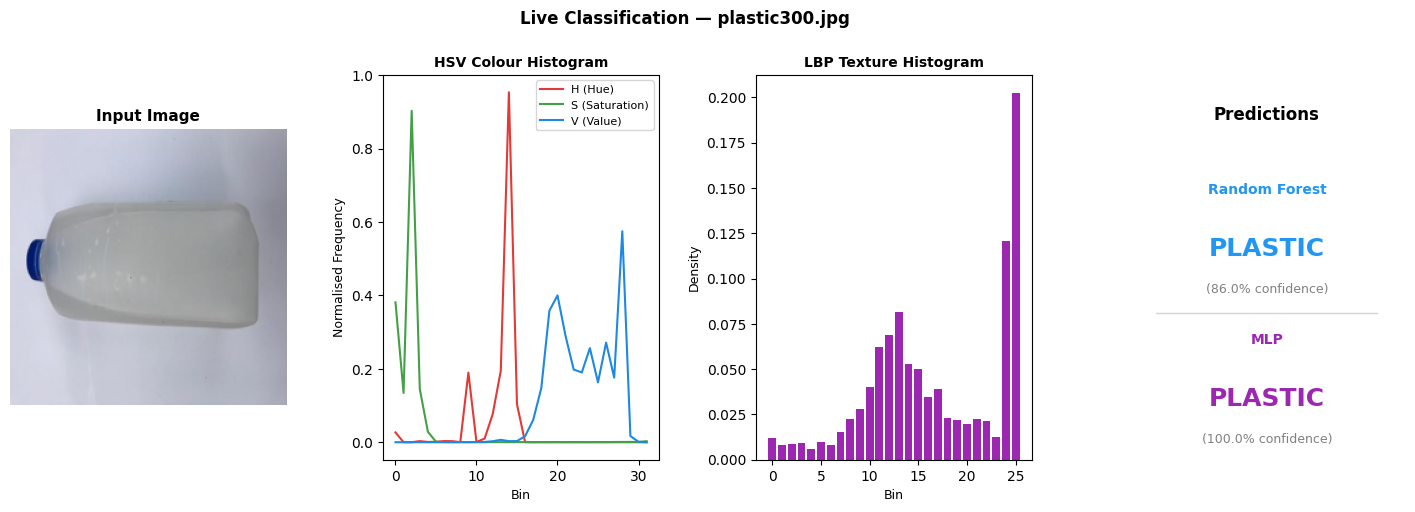


Feature vector: 122 dimensions  (96 HSV colour + 26 LBP texture)
Random Forest  → plastic       (86.0% confidence)
MLP            → plastic       (100.0% confidence)


In [5]:
# Extracts features from the target image and runs it through both classifiers; displays the image,
# the HSV+LBP feature histograms, and each model's prediction with class probabilities

features    = extract_features(IMAGE_PATH)
features_2d = features.reshape(1, -1)

rf_pred        = rf.predict(features_2d)[0]
rf_proba       = rf.predict_proba(features_2d)[0]
rf_confidence  = rf_proba.max() * 100

mlp_pred       = mlp.predict(scaler.transform(features_2d))[0]
mlp_proba      = mlp.predict_proba(scaler.transform(features_2d))[0]
mlp_confidence = mlp_proba.max() * 100

rf_classes  = rf.classes_
mlp_classes = mlp.classes_

# ── Figure layout: image | HSV histograms | LBP histogram | predictions ──

fig = plt.figure(figsize=(18, 5))
gs  = fig.add_gridspec(1, 4, wspace=0.35)

# Panel 1 — input image
ax_img = fig.add_subplot(gs[0])
img_display = np.array(Image.open(IMAGE_PATH).convert('RGB').resize(IMAGE_SIZE))
ax_img.imshow(img_display)
ax_img.set_title("Input Image", fontsize=11, fontweight='bold')
ax_img.axis('off')

# Panel 2 — HSV histograms
ax_hsv = fig.add_subplot(gs[1])
hsv_colours = ['#E53935', '#43A047', '#1E88E5']   # H red, S green, V blue
hsv_labels  = ['H (Hue)', 'S (Saturation)', 'V (Value)']
x_bins = np.arange(HISTOGRAM_BINS)
for ch, (col, lbl) in enumerate(zip(hsv_colours, hsv_labels)):
    ax_hsv.plot(x_bins, features[ch * HISTOGRAM_BINS:(ch + 1) * HISTOGRAM_BINS],
                color=col, label=lbl, linewidth=1.5)
ax_hsv.set_title("HSV Colour Histogram", fontsize=10, fontweight='bold')
ax_hsv.set_xlabel("Bin", fontsize=9)
ax_hsv.set_ylabel("Normalised Frequency", fontsize=9)
ax_hsv.legend(fontsize=8)

# Panel 3 — LBP histogram
ax_lbp = fig.add_subplot(gs[2])
lbp_features = features[96:]
ax_lbp.bar(np.arange(len(lbp_features)), lbp_features, color='#9C27B0', width=0.8)
ax_lbp.set_title("LBP Texture Histogram", fontsize=10, fontweight='bold')
ax_lbp.set_xlabel("Bin", fontsize=9)
ax_lbp.set_ylabel("Density", fontsize=9)

# Panel 4 — predictions
ax_pred = fig.add_subplot(gs[3])
ax_pred.axis('off')

rf_color  = '#2196F3' if rf_pred  == TRUE_LABEL else '#E53935'
mlp_color = '#2196F3' if mlp_pred == TRUE_LABEL else '#E53935'

ax_pred.text(0.5, 0.92, "Predictions",
             ha='center', va='top', fontsize=12, fontweight='bold',
             transform=ax_pred.transAxes)

ax_pred.text(0.5, 0.72, f"Random Forest",
             ha='center', va='top', fontsize=10, color='#2196F3', fontweight='bold',
             transform=ax_pred.transAxes)
ax_pred.text(0.5, 0.58, f"{rf_pred.upper()}",
             ha='center', va='top', fontsize=18, fontweight='bold', color='#2196F3',
             transform=ax_pred.transAxes)
ax_pred.text(0.5, 0.46, f"({rf_confidence:.1f}% confidence)",
             ha='center', va='top', fontsize=9, color='grey',
             transform=ax_pred.transAxes)

ax_pred.axhline(y=0.38, xmin=0.1, xmax=0.9, color='lightgrey', linewidth=1)

ax_pred.text(0.5, 0.33, f"MLP",
             ha='center', va='top', fontsize=10, color='#9C27B0', fontweight='bold',
             transform=ax_pred.transAxes)
ax_pred.text(0.5, 0.19, f"{mlp_pred.upper()}",
             ha='center', va='top', fontsize=18, fontweight='bold', color='#9C27B0',
             transform=ax_pred.transAxes)
ax_pred.text(0.5, 0.07, f"({mlp_confidence:.1f}% confidence)",
             ha='center', va='top', fontsize=9, color='grey',
             transform=ax_pred.transAxes)

fig.suptitle(
    f"Live Classification — {os.path.basename(IMAGE_PATH)}",
    fontsize=12, fontweight='bold', y=1.01
)

# gridspec already sets the spacing; tight_layout conflicts with it
plt.show()

print(f"\nFeature vector: {features.shape[0]} dimensions  "
      f"(96 HSV colour + 26 LBP texture)")
print(f"Random Forest  → {rf_pred:<12}  ({rf_confidence:.1f}% confidence)")
print(f"MLP            → {mlp_pred:<12}  ({mlp_confidence:.1f}% confidence)")

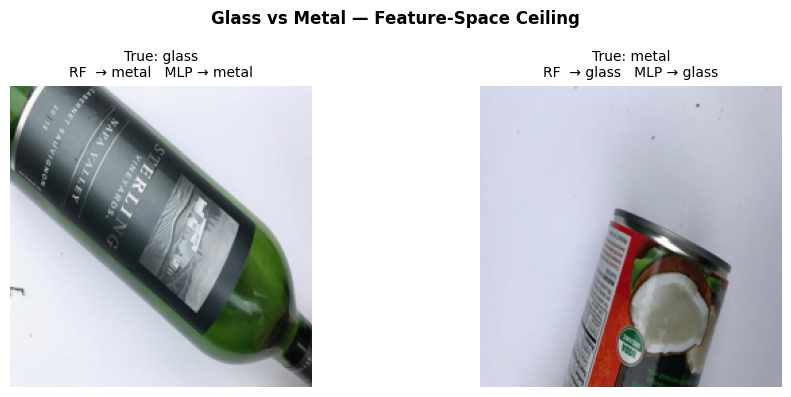

Both classifiers share the same confusion because the HSV+LBP
feature space cannot separate these two classes — not a model problem.


In [ ]:
# Runs both classifiers on a glass image and a metal image side-by-side to demonstrate
# the bidirectional glass–metal confusion that persists across both classifier families.
# Transparent glass lets the grey background dominate the histogram and metal is specular
# grey, so both land in the same low-saturation region of the HSV+LBP feature space.

GLASS_PATH = os.path.join('images', 'glass480.jpg')
METAL_PATH = os.path.join('images', 'metal218.jpg')

def classify(image_path):
    feat    = extract_features(image_path).reshape(1, -1)
    rf_p    = rf.predict(feat)[0]
    mlp_p   = mlp.predict(scaler.transform(feat))[0]
    return rf_p, mlp_p

gl_rf, gl_mlp = classify(GLASS_PATH)
mt_rf, mt_mlp = classify(METAL_PATH)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, img_path, true_label, rf_p, mlp_p in zip(
    axes,
    [GLASS_PATH, METAL_PATH],
    ['glass', 'metal'],
    [gl_rf, mt_rf],
    [gl_mlp, mt_mlp]
):
    ax.imshow(np.array(Image.open(img_path).convert('RGB').resize(IMAGE_SIZE)))
    ax.axis('off')
    rf_col  = '#43A047' if rf_p  == true_label else '#E53935'
    mlp_col = '#43A047' if mlp_p == true_label else '#E53935'
    ax.set_title(
        f"True: {true_label}\n"
        f"RF  → {rf_p}   "
        f"MLP → {mlp_p}",
        fontsize=10
    )

fig.suptitle(
    "Glass vs Metal: a representation-level confusion",
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

print("Both classifiers make the same glass/metal error, and so do the linear baselines: the failure tracks the HSV+LBP representation, not the choice of model.")
print("A fine-tuned CNN roughly halves the count but does not change glass/metal's share of the errors that remain. See finding 1 in the README.")